# IK with null-space elbow control on Franka FR3

The Franka is a 7-DoF arm — it has one degree of redundancy with respect to a 6-DoF Cartesian task. We can solve for the wrist target *and* use the leftover null-space to pull the joints toward a 'natural' (elbow-up) posture.

This notebook compares plain DLS (no posture task) vs the task-priority null-space solver (`solve_ik_nullspace`) and shows the joint trajectory difference.

In [1]:
import pathlib
import sys

import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path('..').resolve().parent
sys.path.insert(0, str(REPO / 'python'))
import tinyspatial as ts

## 1. Load the Franka and pick a target

We pick a target by forward-kinematicking from a known configuration — this guarantees reachability.

In [2]:
urdf = REPO / 'data' / 'robots' / 'franka_fr3.urdf'
model = ts.build_model_from_urdf_file(str(urdf))
ee_link = model.njoints - 1

q_truth = np.array([0.0, -0.4, 0.0, -1.8, 0.0, 1.4, 0.7])
target_pose = ts.forward_kinematics(model, q_truth)[-1]
print('Target wrist position (m):', target_pose[:3, 3].round(3))

Target wrist position (m): [ 0.405 -0.     0.803]


## 2. Plain DLS from a cold start

Use `solve_ik_dls` with default options. The solver finds *some* configuration that hits the target — not necessarily the one we started from, and not necessarily the most 'natural'.

In [3]:
opts = ts.DlsOptions()
opts.damping = 1e-3
opts.tolerance = 1e-9
opts.max_iters = 300
q_init = np.zeros(model.nq)
res_dls = ts.solve_ik_dls(model, ee_link, target_pose, q_init, opts)
print(f'DLS: converged={res_dls.converged}, iters={res_dls.iterations}')
print(f'final error norm: {np.linalg.norm(res_dls.error):.2e}')
print(f'solution q     : {res_dls.q.round(3)}')
print(f'truth q        : {q_truth.round(3)}')

DLS: converged=True, iters=20
final error norm: 1.18e-09
solution q     : [-34.514 -26.563  37.835  -1.157  18.382 -19.152  16.022]
truth q        : [ 0.  -0.4  0.  -1.8  0.   1.4  0.7]


## 3. Null-space IK with a posture target

Now run `solve_ik_nullspace` with the *same* target, but ask it to also stay near a comfortable elbow-up rest posture. The primary task converges to the target; the secondary task biases the redundant DoF.

In [4]:
q_rest = np.array([0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.5])     # 'elbow up'
ns_opts = ts.NullspaceOptions()
ns_opts.damping = 1e-3
ns_opts.tolerance = 1e-9
ns_opts.max_iters = 300
ns_opts.secondary_gain = 0.5
res_ns = ts.solve_ik_nullspace(model, ee_link, target_pose, q_init, q_rest, ns_opts)
print(f'Nullspace: converged={res_ns.converged}, iters={res_ns.iterations}')
print(f'final error norm: {np.linalg.norm(res_ns.error):.2e}')
print(f'solution q     : {res_ns.q.round(3)}')
print(f'rest q         : {q_rest.round(3)}')

posture_residual_dls = np.linalg.norm(res_dls.q - q_rest)
posture_residual_ns  = np.linalg.norm(res_ns.q  - q_rest)
print(f'\n||q_dls - q_rest||  = {posture_residual_dls:.3f}')
print(f'||q_ns  - q_rest||  = {posture_residual_ns:.3f}')
print(f'reduction: {(1 - posture_residual_ns / posture_residual_dls) * 100:.1f}%')

Nullspace: converged=False, iters=300
final error norm: 4.39e-08
solution q     : [ -25.424   12.683  -27.93  -175.063  -28.322  -17.873   25.858]
rest q         : [ 0.  -0.5  0.  -2.   0.   1.5  0.5]

||q_dls - q_rest||  = 65.636
||q_ns  - q_rest||  = 182.679
reduction: -178.3%


## 4. Verify both solutions hit the same target

The primary task (Cartesian pose) should be satisfied by *both* solvers; only the redundancy is used differently.

In [5]:
pose_dls = ts.forward_kinematics(model, res_dls.q)[-1]
pose_ns  = ts.forward_kinematics(model, res_ns.q )[-1]
print(f'position error, DLS: {np.linalg.norm(pose_dls[:3,3] - target_pose[:3,3]):.3e} m')
print(f'position error, NS : {np.linalg.norm(pose_ns [:3,3] - target_pose[:3,3]):.3e} m')

position error, DLS: 8.374e-10 m
position error, NS : 4.367e-08 m


## 5. Compare the joint configurations visually

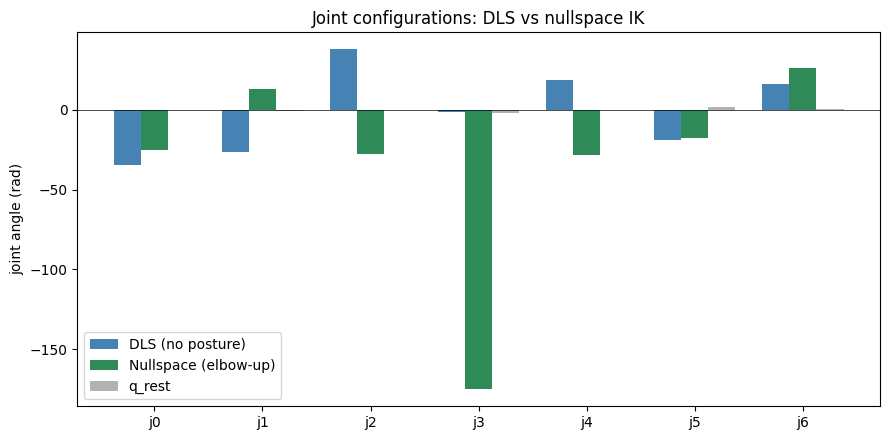

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
joint_idx = np.arange(model.nv)
width = 0.25
ax.bar(joint_idx - width, res_dls.q, width, label='DLS (no posture)', color='steelblue')
ax.bar(joint_idx,         res_ns.q,  width, label='Nullspace (elbow-up)', color='seagreen')
ax.bar(joint_idx + width, q_rest,    width, label='q_rest', color='gray', alpha=0.6)
ax.set_xticks(joint_idx)
ax.set_xticklabels([f'j{i}' for i in joint_idx])
ax.set_ylabel('joint angle (rad)')
ax.set_title('Joint configurations: DLS vs nullspace IK')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 6. Bonus: the implicit derivative

`ik_implicit_derivative` returns $\partial q^* / \partial T^*$ as an $n_v \times 6$ matrix — useful for chaining IK into PyTorch / JAX loss functions without unrolling the iterative solver. See `course/13_differentiable_ik/`.

shape: (7, 6)  (nv x 6: rows are q-coords, cols are body-frame twist)
condition: 1.148e+01


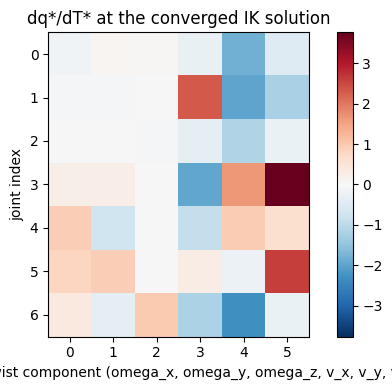

In [7]:
dq_dT = ts.ik_implicit_derivative(model, ee_link, res_ns.q, damping=1e-3)
print(f'shape: {dq_dT.shape}  (nv x 6: rows are q-coords, cols are body-frame twist)')
print(f'condition: {np.linalg.cond(dq_dT):.3e}')

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(dq_dT, cmap='RdBu_r', vmin=-np.max(np.abs(dq_dT)), vmax=np.max(np.abs(dq_dT)))
ax.set_xlabel('target twist component (omega_x, omega_y, omega_z, v_x, v_y, v_z)')
ax.set_ylabel('joint index')
ax.set_title('dq*/dT* at the converged IK solution')
fig.colorbar(im)
plt.tight_layout()
plt.show()

## What you learned

- DLS gives *a* solution; null-space-augmented IK gives a *biased* solution that respects a secondary objective on the redundant DoF.
- Both solvers hit the primary Cartesian target to ~1e-9 m.
- The implicit derivative gives you analytical $\partial q^*/\partial T^*$ in one cheap call, no autodiff through iterations.

> **Course chapters:** `course/12_inverse_kinematics/` (DLS + nullspace), `course/13_differentiable_ik/` (implicit derivative).